In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import impute
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import TomekLinks

from scipy.stats import chi2_contingency


from funcs import *

set_config(transform_output="pandas")
pd.set_option('future.no_silent_downcasting', True)

# Cargar Datos
Aqui dejamos adjunta la [fuente de los datos](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction).

In [2]:
url = 'https://raw.githubusercontent.com/AitzolSa/dataset/619ecb7ffa2bdfcfb5a589fb8266bcf0db15250d/archive.zip'

print("Descargando y leyendo el dataset...")
X = pd.read_csv(url, compression='zip')

print("Datos cargados con exito:")
X.head()

Descargando y leyendo el dataset...
Datos cargados con exito:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


# Dividir Train, Val y Test

In [3]:
# Dividimos train, test y validacion
semilla = 69

y = X.fraudulent
X_features = X.drop('fraudulent', axis=1)
X_resto, X_test, y_resto, y_test = model_selection.train_test_split(
    X_features, y, random_state=semilla, stratify=y, test_size=0.1
)
X_train, X_val, y_train, y_val = model_selection.train_test_split(
    X_resto, y_resto, random_state=semilla, stratify=y_resto, test_size=0.2
)

print("Train:")
print(X_train.describe())
print()

print("Val:")
print(X_val.describe())
print()

print("Test:")
print(X_test.describe())

Train:
             job_id  telecommuting  has_company_logo  has_questions
count  12873.000000   12873.000000      12873.000000   12873.000000
mean    8919.432533       0.042880          0.796784       0.492737
std     5167.644356       0.202595          0.402408       0.499967
min        2.000000       0.000000          0.000000       0.000000
25%     4408.000000       0.000000          1.000000       0.000000
50%     8935.000000       0.000000          1.000000       0.000000
75%    13380.000000       0.000000          1.000000       1.000000
max    17880.000000       1.000000          1.000000       1.000000

Val:
             job_id  telecommuting  has_company_logo  has_questions
count   3219.000000    3219.000000       3219.000000    3219.000000
mean    8991.802423       0.042249          0.788444       0.483691
std     5157.263804       0.201188          0.408475       0.499812
min        1.000000       0.000000          0.000000       0.000000
25%     4594.500000       0.000000 

# Modelo 

In [4]:
col_id = ["job_id"]

columnas_texto_mejor = [
    "company_profile",
    "description",
    "benefits"
]

cols_base_categoricas = [
    "title",
    "location",
    "department",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

cols_numericas = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

col_salario = ["salary_range"]

# Columnas categóricas que se usan en esta prueba
cols_categoricas_prueba = cols_base_categoricas + columnas_texto_mejor

# Número total de variables que entran antes del selector
n_variables_total = len(cols_categoricas_prueba) + len(cols_numericas)

transformer = ColumnTransformer(transformers=[
    ("imputar_categoricas",
        impute.SimpleImputer(strategy="constant", fill_value="unk"),
        cols_categoricas_prueba),

    ("imputar_salario",
        discretizador_salario(),
        col_salario),

    ("imputar_numericas",
        impute.SimpleImputer(strategy="constant", fill_value=-1),
        cols_numericas),

    ("dropear_id",
        "drop",
        col_id)
],
    remainder="drop",
    verbose_feature_names_out=False
)


numerizar = ColumnTransformer(transformers=[
    ("target_enc",
        preprocessing.TargetEncoder(smooth="auto", random_state=semilla),
        cols_categoricas_prueba + col_salario),

    ("scaler_numericas",
        preprocessing.StandardScaler(),
        cols_numericas)
],
    remainder="drop",
    verbose_feature_names_out=False
)

pipe = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar", minusculizar()),
    ("quitarSimbolos", quitar_simbolos()),
    ("quitarTildes", quitar_tildes()),
    ("rellenar", transformer),
    ("numerizar_y_escalar", numerizar),
    ("seleccion_variables", SelectorCorrelacion(k=9)),
    ("limpieza_ruido",TomekLinks()),
    ("modelo", DecisionTreeClassifier())
])

params = {
    "modelo__criterion": ["gini","entropy"], # CART o C4.5
    "modelo__min_samples_split": [0.01,0.05, 0.1,],
    "modelo__min_samples_leaf": [0.01,0.05, 0.1,],
    "modelo__max_depth": [10,50,100],
    "modelo__ccp_alpha": [0.0, 0.01, 0.1]
    
}

grid = GridSearchCV(
    estimator = pipe,
    param_grid = params,
    scoring = "average_precision",
    return_train_score=True
)

In [5]:
print("Empezando train")
grid.fit(X_train, y_train)
print()

Empezando train



In [7]:
print("Mejor modelo obtenido con los siguientes parametros")
best_params = grid.best_params_

for param, value in best_params.items():
    print("{}: {}".format(param,value))

print()

Mejor modelo obtenido con los siguientes parametros
modelo__ccp_alpha: 0.0
modelo__criterion: gini
modelo__max_depth: 50
modelo__min_samples_leaf: 0.01
modelo__min_samples_split: 0.01



Empezando a predecir train
Empezando a predecir val
Resultado en val: 0.7170670749115484


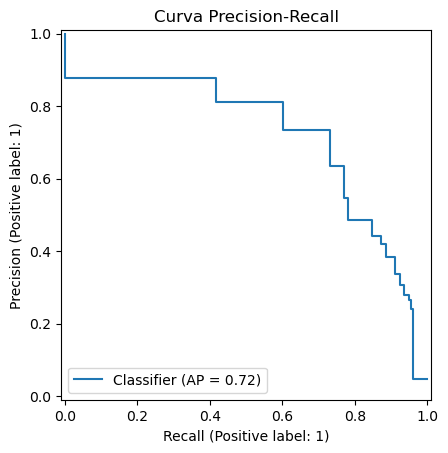

In [8]:
print("Empezando a predecir train")
probs_train = grid.predict_proba(X_train)[:, 1]

print("Empezando a predecir val")
probs_val = grid.predict_proba(X_val)[:, 1]

pr_auc_val = metrics.average_precision_score(
    y_val,
    probs_val
)

print("Resultado en val: {}".format(pr_auc_val))

metrics.PrecisionRecallDisplay.from_predictions(
    y_val,
    probs_val
)

plt.title("Curva Precision-Recall")
plt.show()

# Elegir Mejor Umbral

In [9]:
def clasf_umbral(probs, umbral=0.5):
    preds = np.zeros_like(probs)
    preds[probs > umbral] = 1
    return preds

precision, recall, umbrals = metrics.precision_recall_curve(y_train, probs_train)

rend_umbrals = np.empty_like(umbrals)

for i, umbral in enumerate(umbrals):
    preds = clasf_umbral(probs_val, umbral=umbral)
    
    rend_umbrals[i] = metrics.f1_score(y_val, preds)

indBestUmbral = np.argmax(rend_umbrals)

bestUmbral = umbrals[indBestUmbral]

print('Mejor umbral={:.3f}, Fscore en validacion={:.5f}'.format(bestUmbral, rend_umbrals[indBestUmbral]))

Mejor umbral=0.363, Fscore en validacion=0.73312
